In [4]:
import sys
!{sys.executable} -m pip install scikit-learn

Looking in indexes: https://pypi.org/simple/
     ---------------------------------------- 8.9/8.9 MB 9.8 MB/s eta 0:00:00
     -------------------------------------- 309.1/309.1 kB 9.6 MB/s eta 0:00:00
     ---------------------------------------- 41.3/41.3 MB 7.4 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import seaborn as sns 
import tensorflow as tf 
from tensorflow import keras 
from sklearn.datasets import make_moons
import keras 



making a Vanishing Gradient problem demonstration 

In [8]:
X , y = make_moons(n_samples=10000 , noise=0.1 , random_state=42)


In [11]:
X

array([[ 0.45549318, -0.12550304],
       [-0.70421731,  0.04130827],
       [ 0.41379864,  0.79132194],
       ...,
       [-0.03803096,  0.24540791],
       [ 0.8698024 ,  0.52329471],
       [ 1.16429638, -0.3798397 ]], shape=(10000, 2))

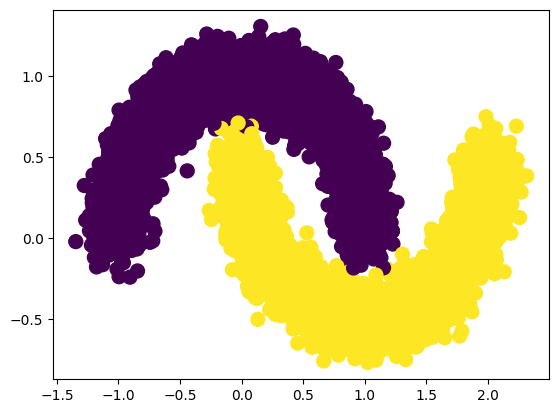

In [9]:
plt.scatter(X[:,0],X[:,1], c=y, s=100)
plt.show()

In [10]:
from tensorflow.keras.layers import Dense , Flatten
from tensorflow.keras.models import Sequential


#### making the model (that is deep enough)

In [12]:
model = Sequential()

model.add(Dense(32 , activation = 'relu' , input_dim =2))
model.add(Dense(32 , activation = 'relu'))
model.add(Dense(32 , activation = 'relu' ))
model.add(Dense(1 , activation = 'sigmoid' ))


C:\Users\manas\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(loss = 'binary_crossentropy' , optimizer = 'adam' , metrics = ['accuracy'])


In [20]:
old_weights = model.get_weights()[0]

In [21]:
history = model.fit(X , y , epochs = 100 , validation_split=0.2 , batch_size = 32 , verbose = 1 , callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss' , patience=10 , restore_best_weights=True)])

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9995 - loss: 0.0013 - val_accuracy: 0.9980 - val_loss: 0.0061
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9991 - loss: 0.0019 - val_accuracy: 0.9995 - val_loss: 0.0014
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9991 - loss: 0.0022 - val_accuracy: 0.9995 - val_loss: 7.8975e-04
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9991 - loss: 0.0017 - val_accuracy: 0.9995 - val_loss: 0.0024
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9991 - loss: 0.0021 - val_accuracy: 0.9985 - val_loss: 0.0057
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9992 - loss: 0.0020 - val_accuracy: 0.9995 - val_loss: 6.9207e-04
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9994 - loss: 0.0016 - val_accuracy: 0.9995 - val_loss: 0.0016
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9994 - loss: 0.0018 - 

In [22]:
new_weights = model.get_weights()[0]

In [23]:
model.optimizer.get_config()["learning_rate"]

0.0010000000474974513

### see the VGP that is old weights and new weights and the percent changes is very small 

In [24]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [25]:
percent_change

array([[ 1.3478624 , 20.786903  ,  0.9733861 ,  3.7835364 ,  1.8595209 ,
         8.485534  , 15.138665  ,  0.5638803 ,  0.24446142, 11.989681  ,
         0.74952435,  1.4343635 ,  0.51694363,  1.613432  ,  1.054983  ,
         0.31026074,  2.9773426 ,  0.12580882,  1.6868271 , 10.056117  ,
         1.2801765 ,  2.0705097 ,  3.7955132 ,  0.8674293 , 78.94939   ,
         1.0598956 ,  3.1022925 , 46.768444  ,  0.82840425,  2.856194  ,
         0.69305646, 17.798294  ],
       [ 3.3849556 ,  4.3453608 ,  0.76467484,  4.943069  ,  0.964296  ,
         0.6122168 ,  3.5309224 ,  0.6011928 ,  8.153663  ,  3.4959922 ,
        47.9473    ,  0.80562425,  4.657974  ,  0.9198237 ,  2.0402052 ,
        11.328623  , 10.883045  ,  2.269748  ,  0.68742156,  1.269781  ,
         3.1003911 ,  1.3479508 ,  1.1273568 ,  5.2848177 ,  2.3980894 ,
        10.541125  , 15.76748   ,  7.521228  ,  2.2227466 , 32.863472  ,
         1.2607847 ,  2.3688486 ]], dtype=float32)

In [26]:
old_weights

array([[ 0.5363949 ,  0.04804372,  0.3131095 , -0.46504173,  0.24326724,
        -0.14440994, -0.06688263,  0.3945682 , -0.71275973, -0.07109161,
        -0.4577798 , -0.43655363,  0.6454607 ,  0.09179031, -0.30277386,
        -0.5231003 , -0.1597629 ,  0.25567085,  0.32296875, -0.09552154,
         0.14590183, -0.42635474, -0.13479704, -0.58617955, -0.00876069,
        -0.4051603 , -0.51024413, -0.03080921,  0.55985194, -0.15893388,
        -0.52477914, -0.05062707],
       [ 0.2158883 , -0.40646583,  0.324469  , -0.42924994,  0.48693606,
         0.52324474, -0.27215242,  0.37673226, -0.08139516, -0.27086842,
        -0.01739388,  0.28419372, -0.15027864,  0.27598676, -0.06457871,
         0.11483543,  0.2107905 , -0.3983306 , -0.31449264, -0.655445  ,
         0.22362909,  0.34307307,  0.3219377 , -0.13480927, -0.72652566,
         0.03648172,  0.11979533, -0.15303828,  0.5061019 ,  0.04278295,
         0.19677618, -0.8610742 ]], dtype=float32)

In [27]:
new_weights

array([[ 0.54362476,  0.05803053,  0.31615725, -0.4474467 ,  0.24779084,
        -0.13215598, -0.07700777,  0.3967931 , -0.71450216, -0.07961527,
        -0.46121097, -0.4428154 ,  0.64212406,  0.09327129, -0.30596808,
        -0.5247233 , -0.1645196 ,  0.2559925 ,  0.31752083, -0.1051273 ,
         0.14776963, -0.43518245, -0.13991328, -0.59126425, -0.00184418,
        -0.40945458, -0.49441487, -0.0452182 ,  0.5644898 , -0.16347334,
        -0.52841616, -0.04161631],
       [ 0.22319603, -0.42412823,  0.32695013, -0.45046806,  0.49163157,
         0.52644813, -0.2817619 ,  0.37899715, -0.08803184, -0.28033796,
        -0.02573378,  0.2819042 , -0.1432787 ,  0.27852535, -0.06326117,
         0.10182615,  0.18785007, -0.4073717 , -0.31233075, -0.6637677 ,
         0.23056246,  0.3384486 ,  0.31830832, -0.1419337 , -0.7439484 ,
         0.03263614,  0.13868403, -0.16454864,  0.51735127,  0.02872299,
         0.1992571 , -0.88147175]], dtype=float32)

## SEcond version of the model building 


In [45]:
Model1 = Sequential()

Model1.add(Dense(10,activation='relu',input_dim=2))
Model1.add(Dense(10,activation='relu'))
Model1.add(Dense(10,activation='relu'))
Model1.add(Dense(10,activation='relu'))
Model1.add(Dense(10,activation='relu'))
Model1.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
Model1.add(Dense(10,activation='relu'))
Model1.add(Dense(10,activation='relu'))
Model1.add(Dense(1, activation='sigmoid'))

C:\Users\manas\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
Model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [36]:
from sklearn.model_selection import train_test_split


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [52]:
old_weights = Model1.get_weights()[0]

In [53]:
Model1.fit(X_train, y_train, epochs = 100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9996 - loss: 9.0423e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9995 - loss: 9.5416e-04
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9992 - loss: 0.0024
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9992 - loss: 0.0016
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9998 - loss: 8.5469e-04
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9996 - loss: 9.5174e-04
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9995 - loss: 0.0018
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9994 - loss: 0.0013    
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9996 - loss: 8.3163e-04
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9995 - loss: 0.0012
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9998 - loss: 4.5196e-04
Epoch 12/100


In [54]:
Model1.optimizer.get_config()["learning_rate"]

0.0010000000474974513

### similar pattern is seen in this model as well as this is more deep model and hence the VGP is more prominent 

In [55]:
new_weights = Model1.get_weights()[0]

In [56]:
Model1.optimizer.get_config()["learning_rate"]

0.0010000000474974513

In [57]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [58]:
gradient

array([[  11.89354  ,  -96.27926  ,   85.71839  ,  -13.362467 ,
         -43.823704 ,   78.941696 ,   -4.9930363,  -17.930387 ,
          18.89548  ,   54.22586  ],
       [ -14.655292 ,    1.4780759,  -28.443007 ,  -30.123232 ,
         153.54495  ,   50.390182 ,  -35.085766 , -109.26172  ,
         121.08778  ,  206.18579  ]], dtype=float32)

In [59]:
percent_change

array([[3.0574806e+00, 2.3305405e+01, 9.7299318e+00, 2.0479662e+00,
        5.5339634e+01, 1.2667795e+01, 3.2115235e+00, 2.2556136e+00,
        1.8921933e+02, 7.7308912e+00],
       [2.5937376e+00, 2.8271818e-01, 7.4839287e+00, 5.2470369e+00,
        2.5084036e+01, 4.9403925e+02, 1.5617349e+01, 3.4196285e+01,
        1.1529466e+01, 2.3889728e+02]], dtype=float32)

In [60]:
old_weights

array([[ 0.3889981 , -0.41311988, -0.8809763 ,  0.652475  ,  0.07919045,
        -0.62316847, -0.15547252,  0.7949229 , -0.00998602,  0.70141804],
       [ 0.565026  ,  0.52280897,  0.3800545 ,  0.5740999 , -0.61212224,
        -0.01019963,  0.22465894,  0.31951344, -1.0502464 , -0.0863073 ]],
      dtype=float32)

In [61]:
new_weights

array([[ 0.37710455, -0.31684062, -0.9666947 ,  0.66583747,  0.12301415,
        -0.7021102 , -0.15047948,  0.8128533 , -0.0288815 ,  0.6471922 ],
       [ 0.5796813 ,  0.5213309 ,  0.4084975 ,  0.60422313, -0.7656672 ,
        -0.06058982,  0.2597447 ,  0.42877516, -1.1713341 , -0.2924931 ]],
      dtype=float32)